In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import iplot , plot
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import plotly.io as pio
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler , LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report , accuracy_score , confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE

In [2]:
df =pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.shape

(45000, 14)

In [4]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'], normalize='index')

loan_status,0,1
previous_loan_defaults_on_file,,
No,0.54837,0.45163
Yes,1.00000,0.00000


In [8]:
df = df.drop(columns=['previous_loan_defaults_on_file'])

In [9]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,1


In [10]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

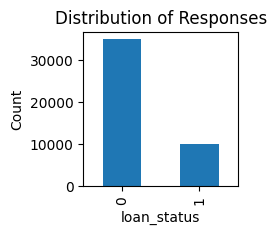

In [11]:
value_counts = df['loan_status'].value_counts()

plt.figure(figsize=(2, 2))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('loan_status')
plt.ylabel('Count')
plt.title('Distribution of Responses')

# Show the plot
plt.show()

In [12]:
def detect_outliers_iqr(df, columns, threshold = 1.5):
    
    outlier_indices = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Finding outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index.tolist()
        outlier_indices[col] = outliers
    
    return outlier_indices

numerical_columns = ['person_age','person_income','person_emp_exp','loan_amnt','loan_int_rate','loan_percent_income',
                     'cb_person_cred_hist_length','credit_score']
outliers_iqr = detect_outliers_iqr(df, numerical_columns)

for col, indices in outliers_iqr.items():
    print(f"{col}: {len(indices)} outliers detected")

person_age: 2188 outliers detected
person_income: 2218 outliers detected
person_emp_exp: 1724 outliers detected
loan_amnt: 2348 outliers detected
loan_int_rate: 124 outliers detected
loan_percent_income: 744 outliers detected
cb_person_cred_hist_length: 1366 outliers detected
credit_score: 467 outliers detected


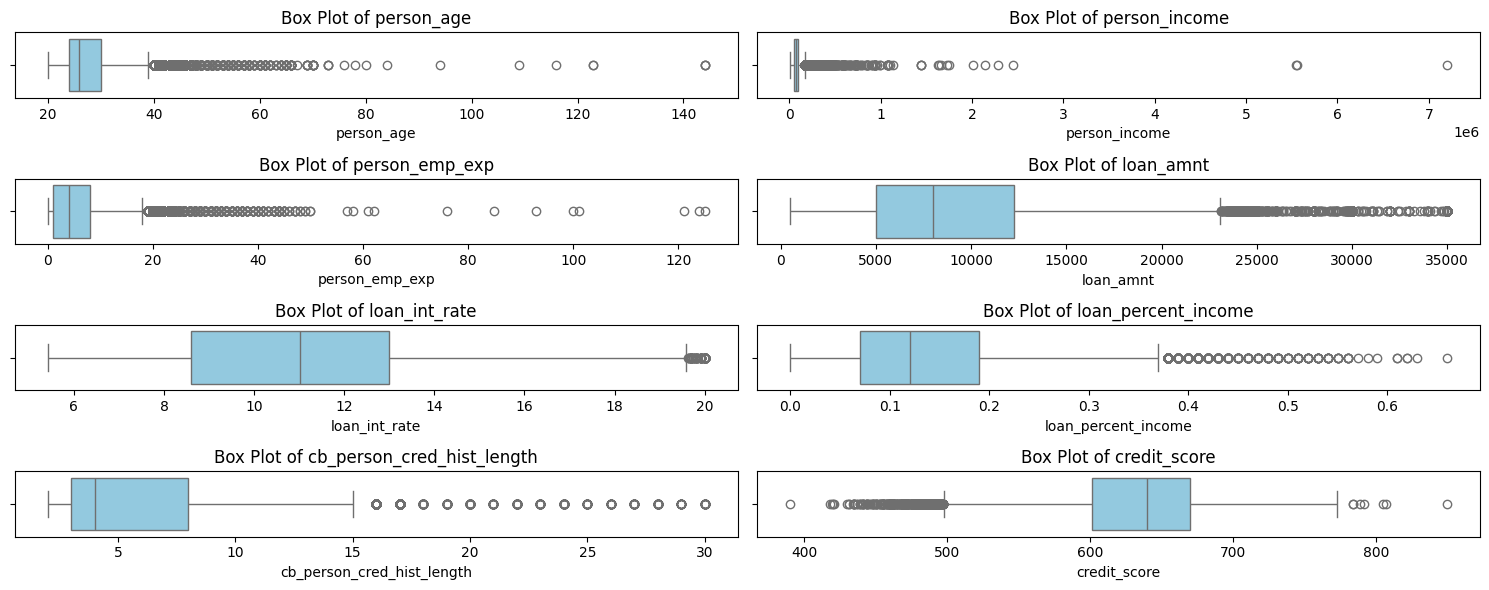

In [13]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)  
    sns.boxplot(x = df[col], color = "skyblue")
    plt.title(f"Box Plot of {col}")

plt.tight_layout() 
plt.show()

In [14]:

def remove_outliers(df, columns, threshold = 1.5):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)  # First quartile (25%)
        Q3 = df_clean[col].quantile(0.75)  # Third quartile (75%)
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        df_clean = df_clean[(df_clean[col] > lower_bound) & (df_clean[col] < upper_bound)]
    
    return df_clean

df_cleaned = remove_outliers(df, numerical_columns)

In [15]:
print(f"Number of Row : {df_cleaned.shape[0]}\nNumber of Columns : {df_cleaned.shape[1]}")

Number of Row : 35630
Number of Columns : 13


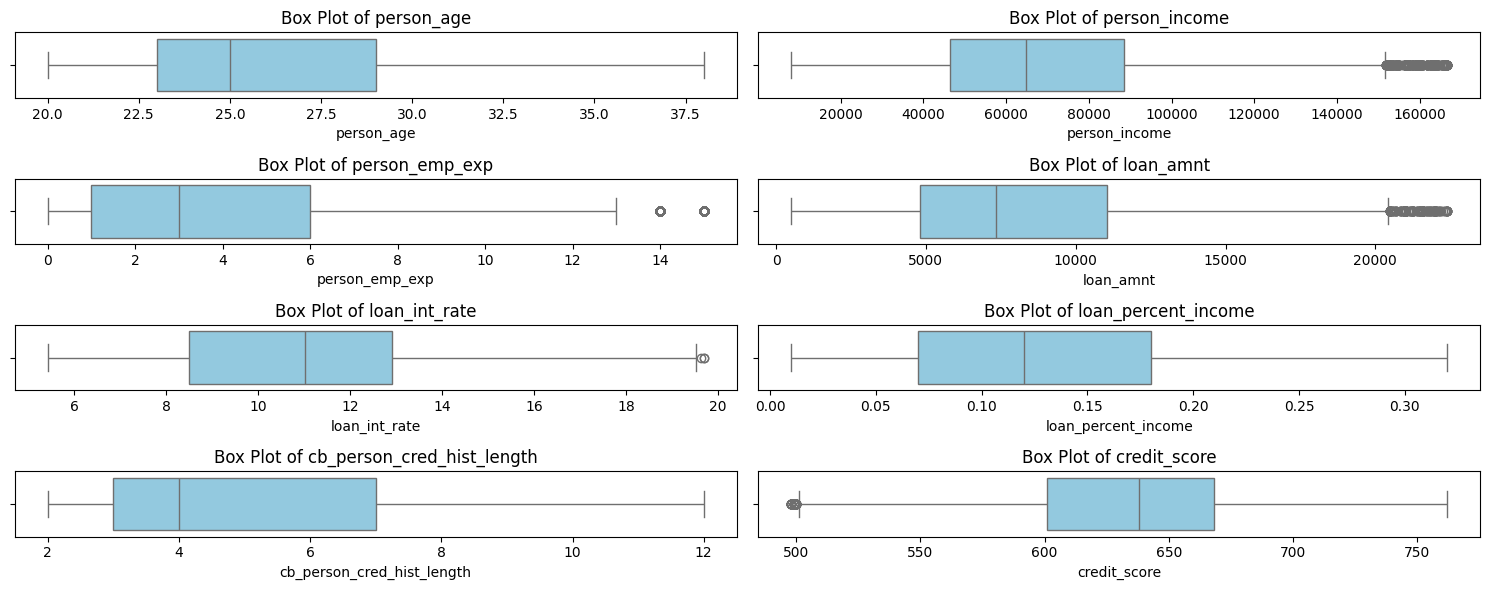

In [16]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i) 
    sns.boxplot(x = df_cleaned[col], color = "skyblue")
    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

In [17]:
df_cleaned.reset_index(inplace = True , drop = True)
df_cleaned.sample(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
18811,28.0,female,Master,28674.0,9,RENT,6000.0,MEDICAL,8.88,0.21,5.0,682,0
18264,33.0,male,High School,53675.0,10,MORTGAGE,9275.0,EDUCATION,7.29,0.17,7.0,678,0
4665,22.0,female,Bachelor,55048.0,1,MORTGAGE,10000.0,EDUCATION,7.88,0.18,4.0,689,0
29544,33.0,male,Associate,146146.0,12,MORTGAGE,15200.0,MEDICAL,13.61,0.10,6.0,645,0
9681,26.0,female,Associate,84776.0,5,MORTGAGE,20000.0,HOMEIMPROVEMENT,14.27,0.24,4.0,606,0


In [18]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35630 entries, 0 to 35629
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  35630 non-null  float64
 1   person_gender               35630 non-null  object 
 2   person_education            35630 non-null  object 
 3   person_income               35630 non-null  float64
 4   person_emp_exp              35630 non-null  int64  
 5   person_home_ownership       35630 non-null  object 
 6   loan_amnt                   35630 non-null  float64
 7   loan_intent                 35630 non-null  object 
 8   loan_int_rate               35630 non-null  float64
 9   loan_percent_income         35630 non-null  float64
 10  cb_person_cred_hist_length  35630 non-null  float64
 11  credit_score                35630 non-null  int64  
 12  loan_status                 35630 non-null  int64  
dtypes: float64(6), int64(3), object

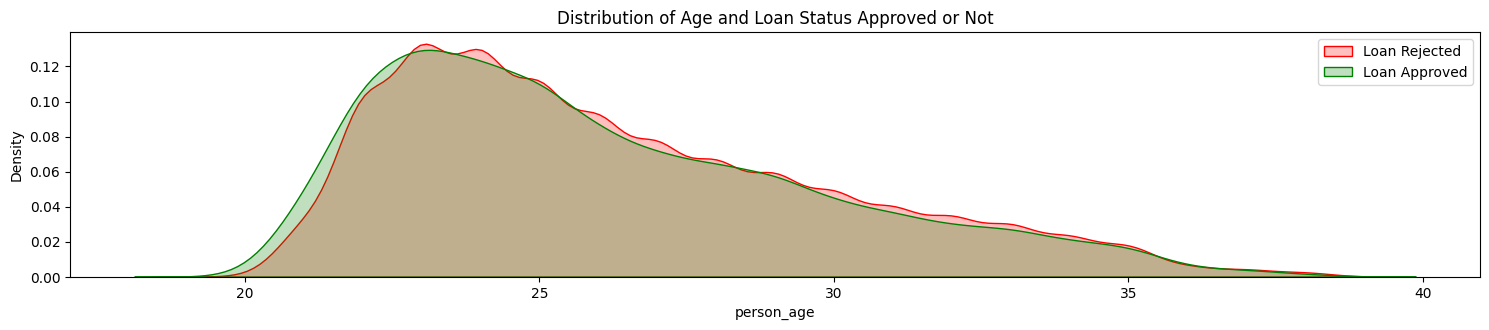

In [19]:
plt.figure(figsize=(15,6))

plt.subplot(2,1,1)

plt.title('Distribution of Age and Loan Status Approved or Not')
sns.kdeplot(df_cleaned[(df_cleaned['loan_status'] == 0)]['person_age'],color='red',fill=True,label='Loan Rejected')
sns.kdeplot(df_cleaned[(df_cleaned['loan_status'] == 1)]['person_age'],color='green',fill=True,label='Loan Approved')

plt.legend()
plt.tight_layout()
plt.show()

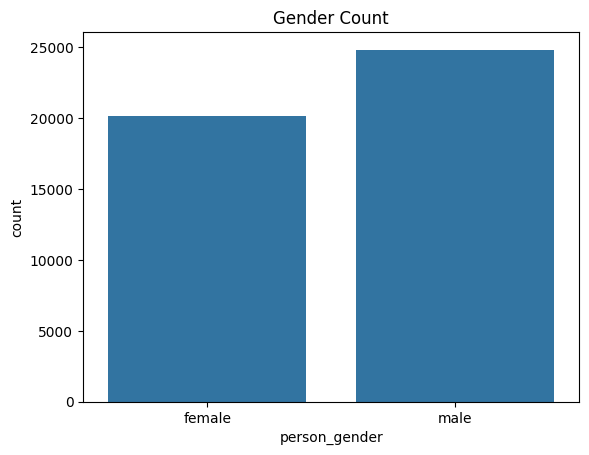

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='person_gender')
plt.title('Gender Count')
plt.show()

In [21]:
gender_percent = df['person_gender'].value_counts(normalize=True) * 100

print(gender_percent)

person_gender
male      55.202222
female    44.797778
Name: proportion, dtype: float64


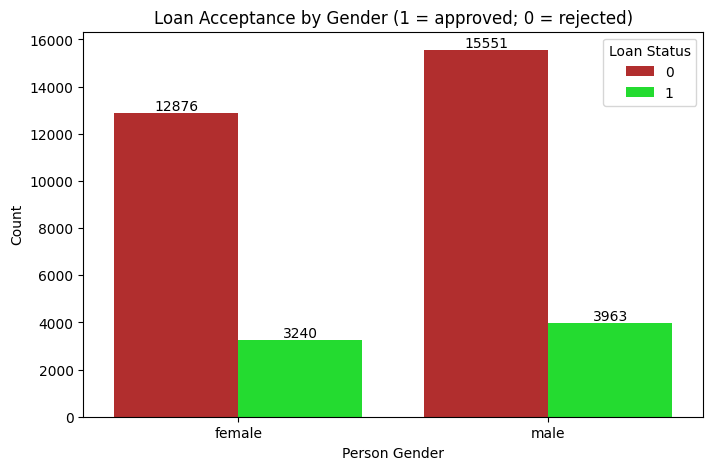

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_cleaned,
    x='person_gender',
    hue='loan_status',
    palette={0: '#c71818', 1: '#05fa15'}
)

plt.title('Loan Acceptance by Gender (1 = approved; 0 = rejected)')
plt.xlabel('Person Gender')
plt.ylabel('Count')
plt.legend(title='Loan Status')


ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container)

plt.show()

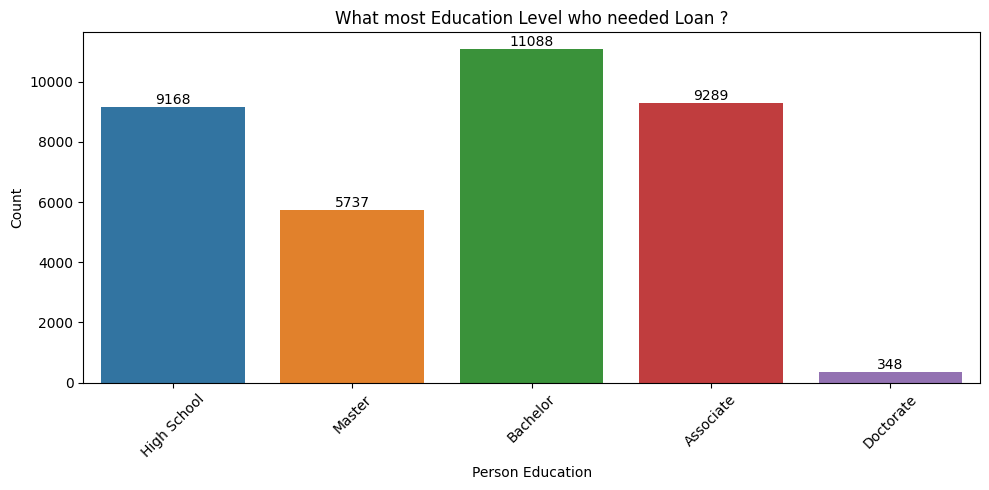

In [ ]:


plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df_cleaned,
    x='person_education',
    hue='person_education',
    legend=False
)

plt.title('What most Education Level who needed Loan ?')
plt.xlabel('Person Education')
plt.ylabel('Count')
plt.xticks(rotation=45)


for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

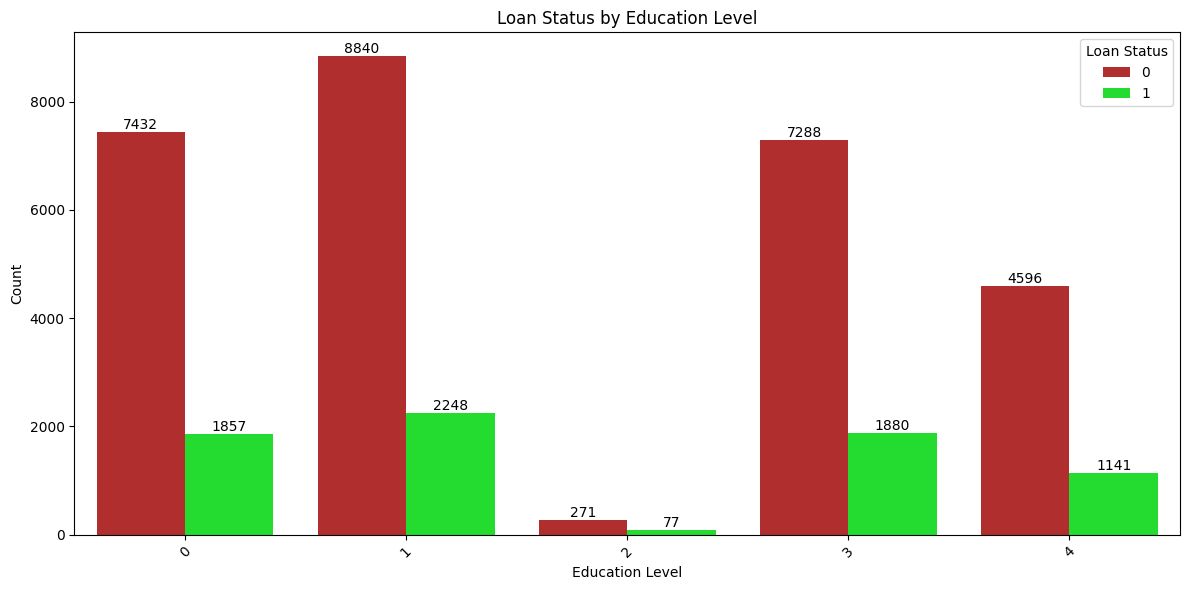

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_cleaned,
    x='person_education',
    hue='loan_status',
    palette={0: '#c71818', 1: '#05fa15'}
)

plt.title('Loan Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Loan Status')

# Count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [25]:
df.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,1


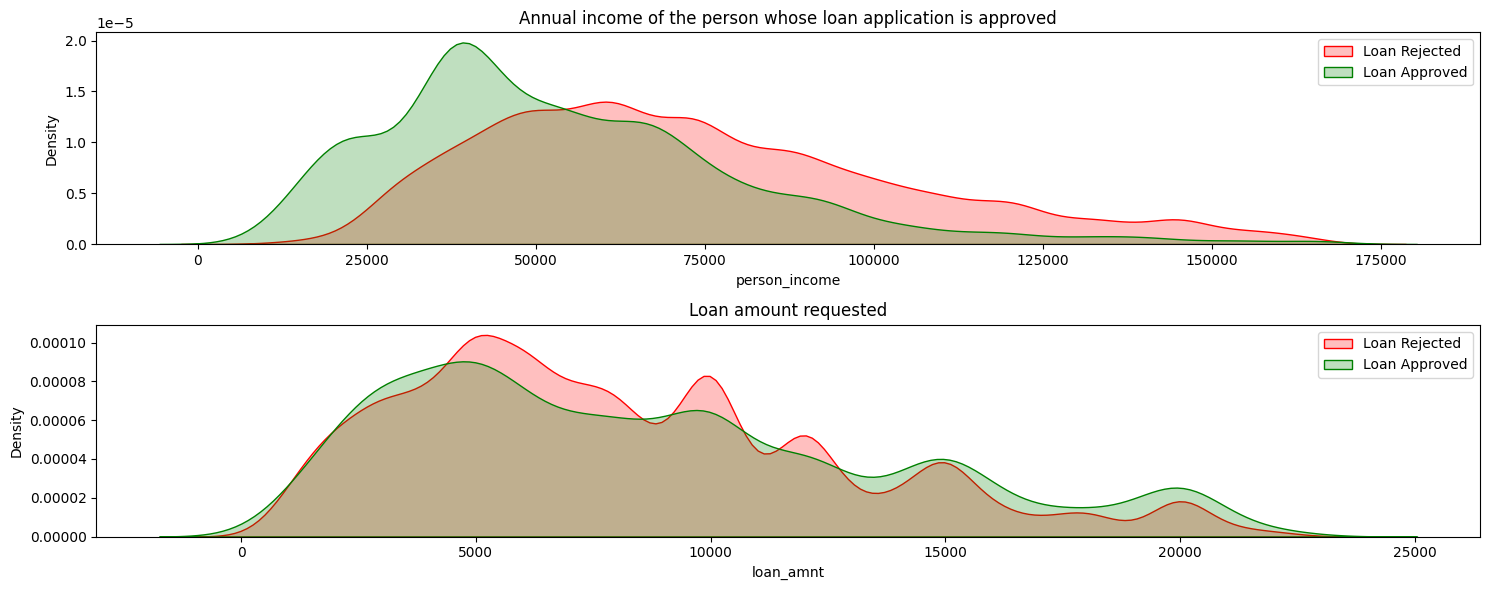

In [26]:
plt.figure(figsize=(15,6))

plt.subplot(2,1,1)

plt.title('Annual income of the person whose loan application is approved')
sns.kdeplot(df_cleaned[(df_cleaned['loan_status'] == 0)]['person_income'],color='red',fill=True,label='Loan Rejected')
sns.kdeplot(df_cleaned[(df_cleaned['loan_status'] == 1)]['person_income'],color='green',fill=True,label='Loan Approved')

plt.legend()

plt.subplot(2,1,2)

plt.title('Loan amount requested')
sns.kdeplot(df_cleaned[(df_cleaned['loan_status'] == 0)]['loan_amnt'],color='red',fill=True,label='Loan Rejected')
sns.kdeplot(df_cleaned[(df_cleaned['loan_status'] == 1)]['loan_amnt'],color='green',fill=True,label='Loan Approved')

plt.legend()
plt.tight_layout()
plt.show()

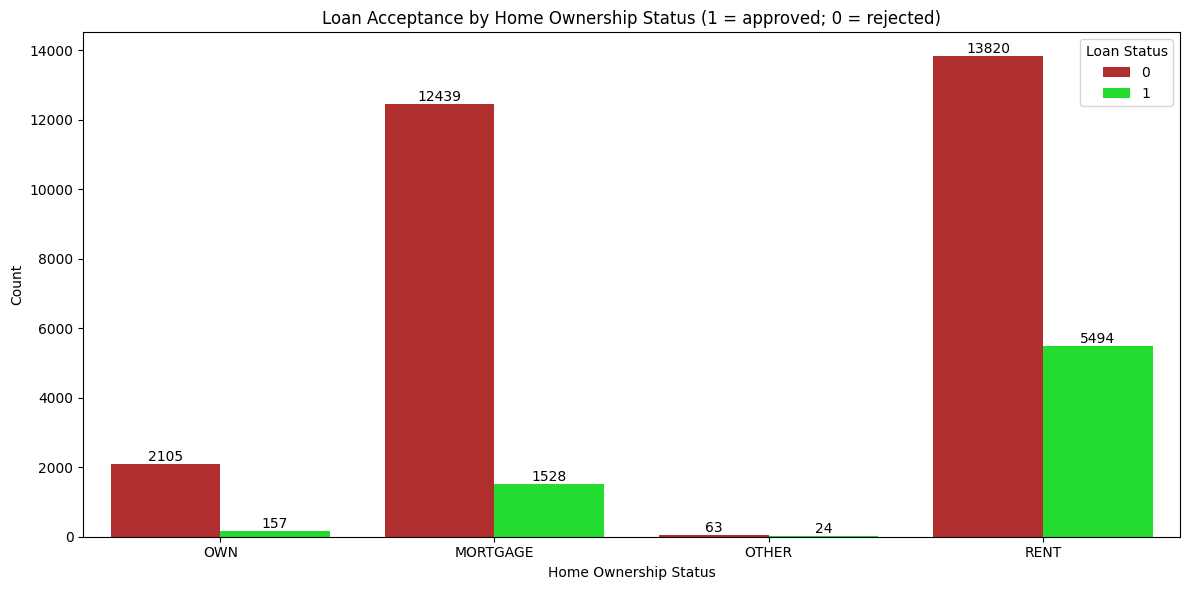

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_cleaned,
    x='person_home_ownership',
    hue='loan_status',
    palette={0: '#c71818', 1: '#05fa15'}
)

plt.title('Loan Acceptance by Home Ownership Status (1 = approved; 0 = rejected)')
plt.xlabel('Home Ownership Status')
plt.ylabel('Count')
plt.legend(title='Loan Status')

# Count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [28]:
column_to_encode = df_cleaned.select_dtypes(object).columns.tolist()
le = LabelEncoder()
for column in column_to_encode:
    df_cleaned[column] = le.fit_transform(df_cleaned[column])

In [29]:
df_cleaned.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,0
1,21.0,0,3,12951.0,0,2,2500.0,5,7.14,0.19,2.0,532,1
2,21.0,0,3,12739.0,0,2,1600.0,5,14.74,0.13,3.0,640,1
3,24.0,0,4,14283.0,1,0,1750.0,1,10.99,0.12,2.0,679,1
4,24.0,0,1,13866.0,0,2,1500.0,4,7.29,0.11,3.0,600,0


In [30]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('loan_status', axis=1)
y = df_cleaned['loan_status']

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

print(x_train.shape)
print(y_train.shape)

(26722, 12)
(26722,)


In [31]:
print(x_train.dtypes)

person_age                    float64
person_gender                   int64
person_education                int64
person_income                 float64
person_emp_exp                  int64
person_home_ownership           int64
loan_amnt                     float64
loan_intent                     int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_cred_hist_length    float64
credit_score                    int64
dtype: object


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

my_params = {
    'n_estimators': [100, 200, 300, 500],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_depth': [5, 10, 15, 20, None],
    'criterion': ['gini', 'entropy']
}

clf = RandomForestClassifier(random_state=42)

model = RandomizedSearchCV(
    estimator=clf,
    param_distributions=my_params,
    n_iter=10,
    cv=4,
    verbose=1,
    random_state=101,
    n_jobs=-1
)

model.fit(x_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,101
,error_score,nan


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

my_params = {
    'n_estimators': [100, 200, 300, 500],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_depth': [5, 10, 15, 20, None],
    'criterion': ['gini', 'entropy']
}

clf = RandomForestClassifier(random_state=42)

model = RandomizedSearchCV(
    estimator=clf,
    param_distributions=my_params,
    n_iter=10,
    cv=4,
    verbose=1,
    random_state=101,
    n_jobs=-1
)

model.fit(x_train, y_train)

In [33]:
best_params = model.best_params_

print("Best Hyperparameters:")
print(best_params)

Best Hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'criterion': 'gini'}


In [34]:
import pickle

filename = 'rf_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [35]:
rf_load = pickle.load(open(filename, 'rb'))

In [36]:
from sklearn.metrics import classification_report

y_pred=model.predict(x_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7096
           1       0.90      0.61      0.73      1812

    accuracy                           0.91      8908
   macro avg       0.91      0.80      0.84      8908
weighted avg       0.91      0.91      0.90      8908

